In [17]:
# ============================================
# PROYECTO: ¿Cuánto gana un Analista BI en LATAM?
# Herramientas: SQL · Python · Power BI
# Autor: [Santiago Castillo Escobar]
# Fecha: 17 Marzo 2025
# Fuentes: Glassdoor, Talently, Coderhouse, Bumeran
# ============================================

In [18]:
# ── 1. IMPORTAR LIBRERÍAS ──

In [19]:
# ── 1. IMPORTAR LIBRERÍAS ──
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


In [20]:
# ── 2. CREAR EL DATASET ──
data = {
    'pais': ['Chile','Chile','Chile',
             'Brasil','Brasil','Brasil',
             'México','México','México',
             'Perú','Perú','Perú',
             'Colombia','Colombia','Colombia',
             'Argentina','Argentina','Argentina'],
    'nivel': ['Junior','Mid','Senior'] * 6,
    'salario_usd_mes': [700,1400,2500,
                        600,1250,2200,
                        530,1113,2385,
                        520,1040,1820,
                        440,880,1320,
                        424,795,1367],
    'modalidad': ['Presencial','Híbrido','Remoto'] * 6
}

df = pd.DataFrame(data)
print("✅ Dataset creado:", df.shape[0], "registros")
df.head(10)

✅ Dataset creado: 18 registros


,pais,nivel,salario_usd_mes,modalidad
0,Chile,Junior,700,Presencial
1,Chile,Mid,1400,Híbrido
2,Chile,Senior,2500,Remoto
3,Brasil,Junior,600,Presencial
4,Brasil,Mid,1250,Híbrido
5,Brasil,Senior,2200,Remoto
6,México,Junior,530,Presencial
7,México,Mid,1113,Híbrido
8,México,Senior,2385,Remoto
9,Perú,Junior,520,Presencial


/tmp/ipykernel_314/2857669127.py:20: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_314/2857669127.py:21: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.savefig('grafica1_salario_pais.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


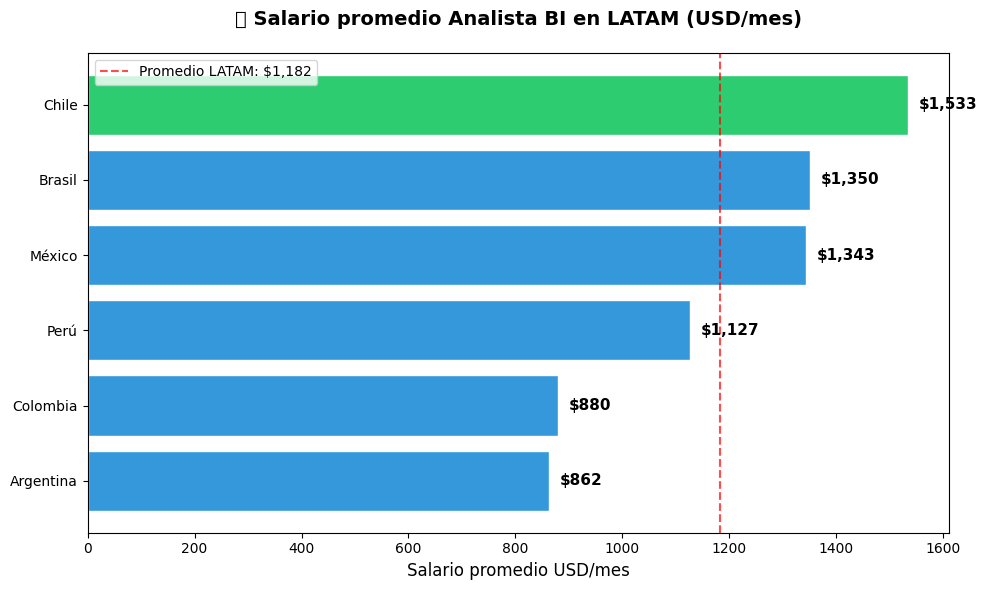

✅ Gráfica 1 guardada


In [21]:
# ── 3. GRÁFICA 1: SALARIO PROMEDIO POR PAÍS ──
plt.figure(figsize=(10, 6))

promedio_pais = df.groupby('pais')['salario_usd_mes'].mean().sort_values(ascending=True)

colores = ['#2ecc71' if p == 'Chile' else '#3498db' for p in promedio_pais.index]

bars = plt.barh(promedio_pais.index, promedio_pais.values, color=colores, edgecolor='white')

for bar, val in zip(bars, promedio_pais.values):
    plt.text(val + 20, bar.get_y() + bar.get_height()/2,
             f'${val:,.0f}', va='center', fontweight='bold', fontsize=11)

plt.title('💰 Salario promedio Analista BI en LATAM (USD/mes)',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Salario promedio USD/mes', fontsize=12)
plt.axvline(x=promedio_pais.mean(), color='red',
            linestyle='--', alpha=0.7, label=f'Promedio LATAM: ${promedio_pais.mean():,.0f}')
plt.legend()
plt.tight_layout()
plt.savefig('grafica1_salario_pais.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica 1 guardada")

/tmp/ipykernel_314/2894326658.py:22: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_314/2894326658.py:23: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig('grafica2_crecimiento.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


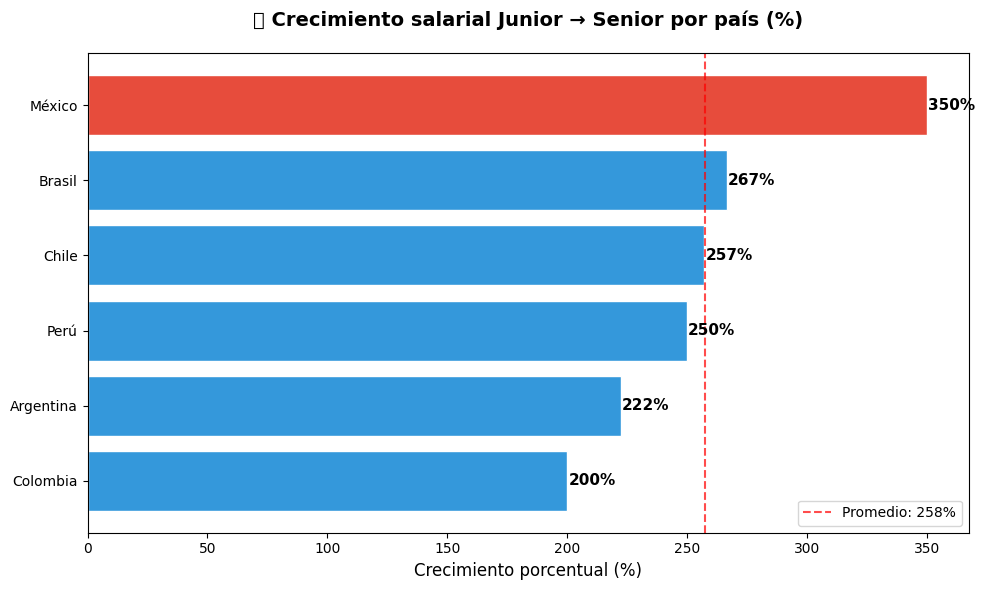

✅ Gráfica 2 guardada


In [22]:
# ── 4. GRÁFICA 2: CRECIMIENTO JUNIOR → SENIOR ──
plt.figure(figsize=(10, 6))

junior = df[df['nivel']=='Junior'].set_index('pais')['salario_usd_mes']
senior = df[df['nivel']=='Senior'].set_index('pais')['salario_usd_mes']
crecimiento = ((senior / junior - 1) * 100).sort_values(ascending=True)

colores = ['#e74c3c' if p == 'México' else '#3498db' for p in crecimiento.index]

bars = plt.barh(crecimiento.index, crecimiento.values, color=colores, edgecolor='white')

for bar, val in zip(bars, crecimiento.values):
    plt.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.0f}%', va='center', fontweight='bold', fontsize=11)

plt.title('📈 Crecimiento salarial Junior → Senior por país (%)',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Crecimiento porcentual (%)', fontsize=12)
plt.axvline(x=crecimiento.mean(), color='red',
            linestyle='--', alpha=0.7, label=f'Promedio: {crecimiento.mean():.0f}%')
plt.legend()
plt.tight_layout()
plt.savefig('grafica2_crecimiento.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica 2 guardada")

/tmp/ipykernel_314/3240172626.py:20: UserWarning: Glyph 128187 (\N{PERSONAL COMPUTER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_314/3240172626.py:21: UserWarning: Glyph 128187 (\N{PERSONAL COMPUTER}) missing from font(s) DejaVu Sans.
  plt.savefig('grafica3_modalidad.png', dpi=150, bbox_inches='tight')


NameError: name 'pl' is not defined

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128187 (\N{PERSONAL COMPUTER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


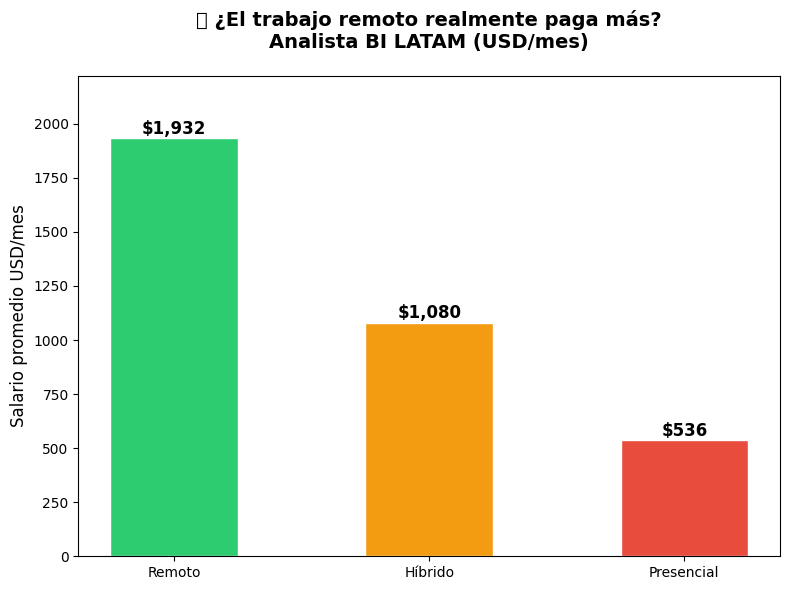

In [23]:
# ── 5. GRÁFICA 3: REMOTO VS PRESENCIAL ──
plt.figure(figsize=(8, 6))

promedio_modalidad = df.groupby('modalidad')['salario_usd_mes'].mean().sort_values(ascending=False)

colores = {'Remoto': '#2ecc71', 'Híbrido': '#f39c12', 'Presencial': '#e74c3c'}
lista_colores = [colores[m] for m in promedio_modalidad.index]

bars = plt.bar(promedio_modalidad.index, promedio_modalidad.values,
               color=lista_colores, edgecolor='white', width=0.5)

for bar, val in zip(bars, promedio_modalidad.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 20,
             f'${val:,.0f}', ha='center', fontweight='bold', fontsize=12)

plt.title('💻 ¿El trabajo remoto realmente paga más?\nAnalista BI LATAM (USD/mes)',
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Salario promedio USD/mes', fontsize=12)
plt.ylim(0, max(promedio_modalidad.values) * 1.15)
plt.tight_layout()
plt.savefig('grafica3_modalidad.png', dpi=150, bbox_inches='tight')
pl

In [ ]:
# ── 6. GRÁFICA 4: HABILIDADES QUE MÁS SUBEN EL SALARIO ──
plt.figure(figsize=(10, 6))

habilidades = {
    'Inglés avanzado': 35.0,
    'Azure': 26.0,
    'Python': 24.3,
    'dbt': 21.5,
    'Power BI': 20.0,
    'SQL': 16.3
}

hdf = pd.Series(habilidades).sort_values(ascending=True)

colores = ['#e74c3c' if h == 'Inglés avanzado' else '#f39c12' if h in ['Azure','Python'] else '#3498db' for h in hdf.index]

bars = plt.barh(hdf.index, hdf.values, color=colores, edgecolor='white')

for bar, val in zip(bars, hdf.values):
    plt.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'+{val}%', va='center', fontweight='bold', fontsize=11)

plt.title('¿Qué habilidad sube más tu salario como Analista BI?', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Incremento salarial promedio (%)', fontsize=12)
plt.axvline(x=hdf.mean(), color='gray', linestyle='--', alpha=0.7, label=f'Promedio: {hdf.mean():.1f}%')
plt.legend()
plt.tight_layout()
plt.savefig('grafica4_habilidades.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica 4 guardada")

In [ ]:
# ── 7. CONCLUSIONES E INSIGHTS ──
print("=" * 50)
print("INSIGHTS: ¿Cuánto gana un Analista BI en LATAM?")
print("=" * 50)
print("")
print("1. Chile paga mas en promedio: $1,533 USD/mes")
print("   y es #1 en todos los niveles")
print("")
print("2. Mexico tiene el mayor crecimiento Junior-Senior")
print("")
print("3. Remoto paga 70% mas que presencial")
print("")
print("4. Ingles avanzado sube el salario +35%")
print("")
print("5. Azure y Python son las mas rentables")
print("   Azure +26% y Python +24%")
print("")
print("=" * 50)
print("Herramientas: SQL - Python - Power BI")
print("Fuentes: Glassdoor - Talently - Coderhouse")
print("Datos: 2024-2025")
print("=" * 50)

In [ ]:
# ── 8. DESCARGAR LAS GRÁFICAS ──
from google.colab import files

files.download('grafica1_salario_pais.png')
files.download('grafica2_crecimiento.png')
files.download('grafica3_modalidad.png')
files.download('grafica4_habilidades.png')

print("✅ Las 4 gráficas se están descargando")